In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/flights.csv")
print(df.shape)
print(df.info())
print(df.describe())


(271888, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB
None
          travelCode       userCode         price           time  \
count  271888.000000  271888.000000  271888.00000  271888.000000   
mean    67971.500000     667.505495     957.37503       1.421147   
std     39243.724665     389.523127     362.31189       0.542541   
min         0.000000       0.000

In [3]:
print(df.isnull().sum())
print(f"Duplicate rows: {df.duplicated().sum()}")


travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64
Duplicate rows: 0


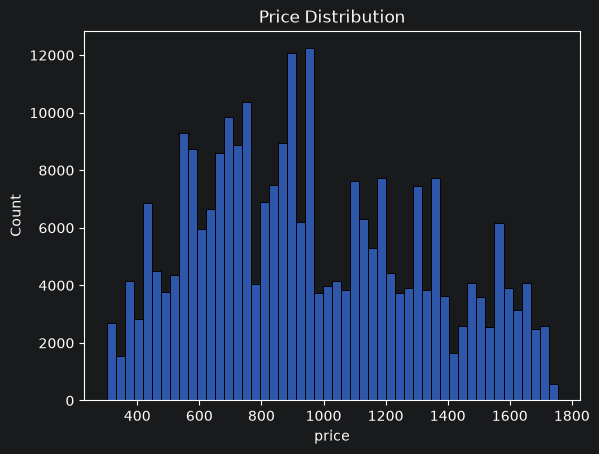

In [4]:
sns.histplot(df["price"], bins=50)
plt.title("Price Distribution")
plt.show()



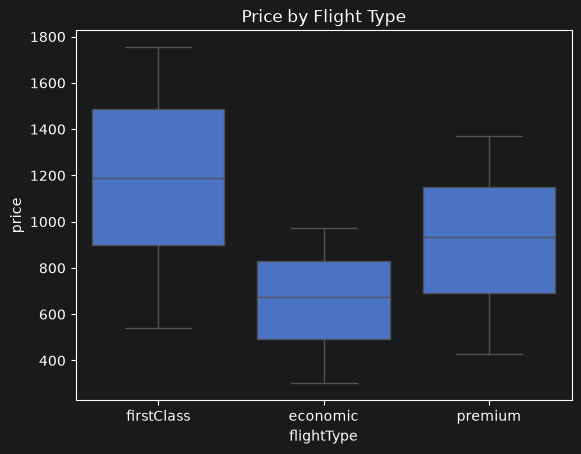

In [5]:
sns.boxplot(x="flightType", y="price", data=df)
plt.title("Price by Flight Type")
plt.show()

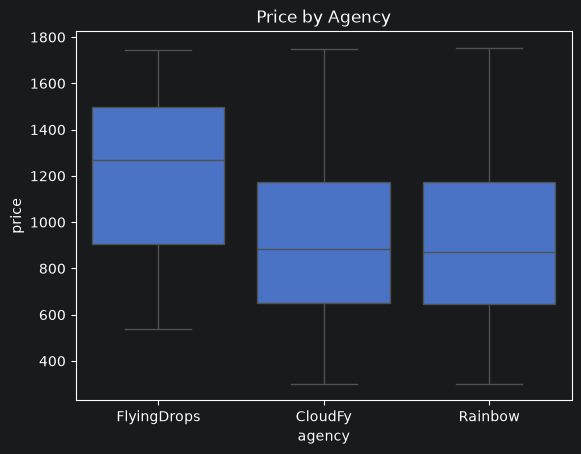

In [6]:
sns.boxplot(x="agency", y="price", data=df)
plt.title("Price by Agency")
plt.show()


In [7]:
print(df[["price", "time", "distance"]].corr())


             price     time  distance
price     1.000000  0.64180  0.641915
time      0.641800  1.00000  0.999990
distance  0.641915  0.99999  1.000000


In [8]:
df["route"] = df["from"] + " -> " + df["to"]
route_avg = df.groupby("route")["price"].mean().sort_values(ascending=False)
print(route_avg)

route
Sao Paulo (SP) -> Florianopolis (SC)         1380.881239
Campo Grande (MS) -> Rio de Janeiro (RJ)     1371.030729
Brasilia (DF) -> Salvador (BH)               1366.796635
Aracaju (SE) -> Salvador (BH)                1364.968773
Rio de Janeiro (RJ) -> Recife (PE)           1361.202604
                                                ...     
Sao Paulo (SP) -> Campo Grande (MS)           486.149024
Aracaju (SE) -> Natal (RN)                    484.108677
Natal (RN) -> Aracaju (SE)                    482.376137
Brasilia (DF) -> Rio de Janeiro (RJ)          481.176384
Florianopolis (SC) -> Rio de Janeiro (RJ)     474.807908
Name: price, Length: 70, dtype: float64
